![Py4Eng](../logo.png)

# Data Augmentation
## Yoav Ram

In this session we will understand:
- why a small convolutional network overfits CIFAR-10, and what that looks like in the training curves
- what *data augmentation* is: random, label-preserving transformations of the training images
- how to put augmentation layers **inside** a Keras model, so they run during training and not at inference
- three defaults in the Keras augmentation layers that quietly do the wrong thing here
- how to measure what augmentation bought, using the train-validation gap and not the accuracy alone

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import time

import numpy as np
import seaborn as sns

import jax
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')

Keras: 3.15.1 backend: jax gpu


The same `plot_history` helper we used in the other Keras sessions:

In [2]:
def plot_history(history, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(history['accuracy'], label='Train')
    ax.plot(history['val_accuracy'], label='Validation')
    ax.set(ylabel='Accuracy', xlabel='Epochs')
    ax.legend()

    ax = axes[1]
    ax.plot(history['loss'], label='Train')
    ax.plot(history['val_loss'], label='Validation')
    ax.set(ylabel='Loss', xlabel='Epochs')
    ax.legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()

# Why augmentation?

Every model we have trained so far has had the same problem running in the background: the training accuracy climbs towards 100% while the validation accuracy flattens out. The network is fitting the particular images it was given rather than the things those images are pictures of.

There are two ways out. One is to constrain the model — that is what `Dropout` and pooling do. The other is to enlarge the *training set*; and since we usually cannot go and collect more labelled photographs, we manufacture more of them out of the ones we have.

**Data augmentation** is the second route: apply a random, *label-preserving* transformation to every training image, every time it is used. A photograph of a horse shifted four pixels to the left, or mirrored, is still a photograph of a horse. The network sees a slightly different image every epoch, so memorizing the training set stops being an easy strategy, and it is pushed towards features that survive the transformation.

"Label-preserving" is doing all the work in that sentence, and it is the reason this session is not on MNIST. A mirrored 2 is not a 2, a 6 rotated far enough is a 9, and at 60,000 images with 99% validation accuracy there is nothing left to win anyway. CIFAR-10 has no digits and no text, its classes are objects photographed in the wild, and a mirrored horse is exactly as much a horse as the original. It is the smallest standard dataset where the transformations are honest **and** where a small network overfits visibly.

One warning about the framing, which we will come back to at the end: augmentation is **not** "more data". The sample size does not change. What changes is the set of functions the network is encouraged to learn — the ones invariant to the transformations we picked.

## The data

CIFAR-10 is 60,000 colour images of 32x32 pixels in 10 classes, 6,000 per class ([Krizhevsky 2009](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf)). Keras ships it, like MNIST, so there is nothing to download by hand.

In [3]:
(X_train, Y_train), (X_validation, Y_validation) = keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255
X_validation = X_validation.astype('float32') / 255
Y_train = keras.utils.to_categorical(Y_train)
Y_validation = keras.utils.to_categorical(Y_validation)
ncats = Y_validation.shape[1]

print('train     ', X_train.shape, Y_train.shape)
print('validation', X_validation.shape, Y_validation.shape)
print('pixels in [{:.0f}, {:.0f}], {} classes'.format(X_train.min(), X_train.max(), ncats))

train      (50000, 32, 32, 3) (50000, 10)
validation (10000, 32, 32, 3) (10000, 10)
pixels in [0, 1], 10 classes


The images are normalized to $[0, 1]$ and the labels are one-hot encoded, exactly as in the [CNN session](K_CNN.ipynb). Keep that $[0, 1]$ in mind: three of the augmentation layers assume $[0, 255]$ unless told otherwise, and we will come back to it.

We use the official 10,000-image test split as our validation set and call it **validation** throughout, as in the other Keras sessions. Nothing here is selected on it — no early stopping, no callbacks, we do not pick an epoch, and we run one seed for a number of epochs fixed in advance. It is being used to measure, not to choose.

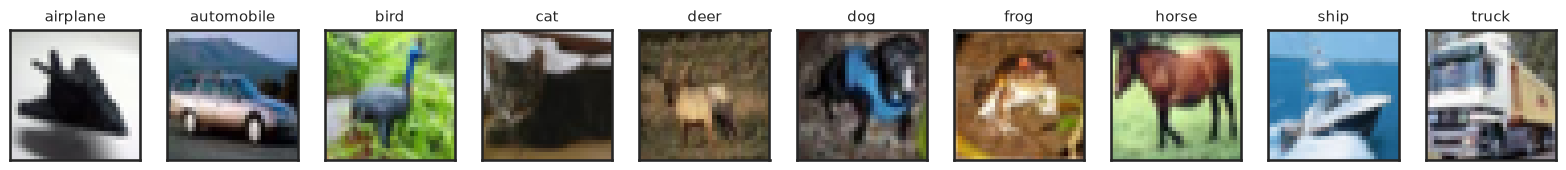

In [4]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

labels = Y_train.argmax(axis=1)
fig, axes = plt.subplots(1, ncats, figsize=(16, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(X_train[labels == k][0])
    ax.set(xticks=[], yticks=[], title=CLASSES[k])
    ax.title.set_fontsize(11)
fig.tight_layout()

# The transformations

Keras 3 provides augmentations as **layers**: `keras.layers.RandomFlip`, `RandomTranslation`, `RandomRotation`, and so on. They behave like any other layer, except that they do something only when `training=True`.

We start with the standard CIFAR recipe, which is deliberately minimal — a horizontal flip and a shift of up to four pixels in each direction, since `0.125 * 32 = 4`:

In [5]:
augment_simple = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.125, 0.125, fill_mode='constant', fill_value=0.0),
], name='augment')

## Three defaults that are wrong here

Every argument above overrides a default, and every one of those defaults fails **silently** — the model trains, the numbers come out worse, and nothing tells you why.

1. **`RandomFlip` defaults to `mode='horizontal_and_vertical'`.** An upside-down ship is not a ship. Vertical flip is not a symmetry of CIFAR-10, and including it teaches the network to be invariant to something the data never does. Pass `'horizontal'`.

2. **`RandomTranslation` defaults to `fill_mode='reflect'`.** When the image shifts, something has to fill the strip it vacated; `reflect` mirrors the image content back into it, duplicating whatever was near the edge. The standard recipe pads with zeros, so we pass `fill_mode='constant', fill_value=0.0`.

3. **`RandomContrast`, `RandomBrightness` and `RandomErasing` default to `value_range=(0, 255)`.** Our pixels are in $[0, 1]$, so with the default these layers compute their effect on a scale 255 times too large. They are not in the recipe above, but they *are* in the exercise at the end of this session — pass `value_range=(0, 1)` when you get there.

The first two are about the data, the third is about the units. All three belong to one category worth remembering: **an augmentation bug does not raise an exception.**

Here is what the recipe actually does. This is the one cell in this session that has to run live — it costs nothing, and it is what makes the mechanism concrete:

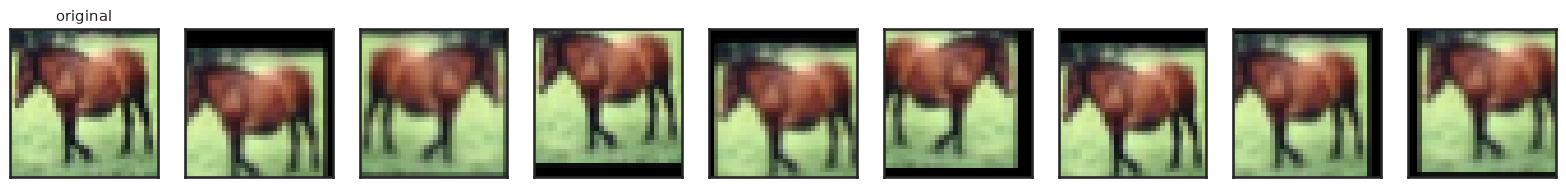

In [6]:
image = X_train[[7]]

fig, axes = plt.subplots(1, 9, figsize=(16, 2.4))
axes[0].imshow(image[0])
axes[0].set(xticks=[], yticks=[], title='original')
axes[0].title.set_fontsize(11)
for ax in axes[1:]:
    ax.imshow(np.asarray(augment_simple(image, training=True))[0])
    ax.set(xticks=[], yticks=[])
fig.tight_layout()

Every one of those images carries the same label, and the network is shown a different one each epoch.

## Where the augmentation goes

We put these layers **inside the model**, as its first layers, rather than transforming the arrays before calling `fit`. Two consequences are worth stating explicitly:

- Keras runs augmentation layers only when `training=True`. So `fit` augments, while `evaluate` and `predict` do not: the validation set is never augmented, and inference is deterministic. Transforming the arrays instead would have meant being careful to transform only the training ones, and to re-randomize them every epoch.
- The layers are saved inside the `.keras` file. A reloaded model still carries them, inert. That is convenient, and it is a small trap of its own — the two models are not the same architecture, so `summary()` differs, even though they have exactly the same weights to learn.

# The model

A small convolutional network in the style of the [CNN session](K_CNN.ipynb): three convolution-and-pooling blocks, a dense layer with dropout, then the softmax.

In [7]:
def build_model(augment=None, seed=SEED):
    keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(32, 32, 3))
    x = augment(inputs) if augment is not None else inputs
    for filters in (32, 64, 128):
        x = keras.layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = keras.layers.MaxPool2D()(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.Dropout(rate=0.5)(x)
    outputs = keras.layers.Dense(ncats, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='cifar_cnn')


build_model().summary()

Model: "cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

Three blocks rather than two wider ones: with only two, the feature map still has 8x8 positions when it reaches `Flatten`, so most of the parameters land in the flatten-to-dense matrix and the receptive field never covers the whole image. Three blocks bring it to 4x4 and put the parameters in the convolutions, where they are shared across positions.

The `Dropout` stays. It is the regularizer from the CNN session, and keeping it means that whatever augmentation buys us is an honest increment *on top of* a model that is already regularized, rather than a win over a straw man.

There is no batch normalization, no learning-rate schedule, no early stopping and no callbacks. `augment` is a parameter of the builder so that the two arms of the experiment differ in exactly one thing, and so that the exercise at the end is a one-cell change.

# The experiment

Two models, identical apart from the augmentation block, the same seed, the same 50 epochs, the same batch size. The budget is fixed in advance, so there is nothing to select.

**Cost, measured.** On an NVIDIA RTX A4000 the unaugmented run took **65 seconds** for all 50 epochs. The augmented run took **4,607 seconds**, about 77 minutes. That is a factor of 71, and it is worth knowing where it goes, because it is not a property of augmentation in general:

| augmentation | ms per step |
|---|---|
| none | 1.3 |
| `RandomFlip` alone | 1.3 |
| `RandomTranslation` alone | 102 |
| both | 157 |

`RandomFlip` is free — it is an indexing operation. `RandomTranslation` costs about eighty times the whole rest of the network, because it applies a per-sample affine transform, and on this backend that is not work the GPU does well: during the augmented run the GPU sits at a few percent utilization. Our model is tiny, so the augmentation dominates completely. On a bigger network the ratio would be far less alarming.

The training cells below are left as they were run. **In class, comment them out and start from the load cell**, which reads the saved models back in — the whole notebook then runs in seconds.

In [8]:
model_noaug = build_model(augment=None)
model_noaug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_noaug = model_noaug.fit(
    x=X_train, y=Y_train, batch_size=64, epochs=50,
    validation_data=(X_validation, Y_validation), verbose=2,
).history
print('Trained in {:.0f}s'.format(time.time() - t0))

Epoch 1/50


782/782 - 6s - 8ms/step - accuracy: 0.4350 - loss: 1.5501 - val_accuracy: 0.5663 - val_loss: 1.2207


Epoch 2/50


782/782 - 1s - 1ms/step - accuracy: 0.6005 - loss: 1.1320 - val_accuracy: 0.6472 - val_loss: 0.9967


Epoch 3/50


...

Epoch 49/50


782/782 - 1s - 1ms/step - accuracy: 0.9541 - loss: 0.1328 - val_accuracy: 0.7522 - val_loss: 1.4931


Epoch 50/50


782/782 - 1s - 1ms/step - accuracy: 0.9552 - loss: 0.1300 - val_accuracy: 0.7558 - val_loss: 1.5190


Trained in 62s


Save the unaugmented model and its history:

In [9]:
model_noaug.save('../data/cifar10_noaug.keras')
with open('../data/cifar10_noaug_history.p', 'wb') as f:
    pickle.dump(history_noaug, f)

Now the same model with the augmentation block in front of it:

In [10]:
model_aug = build_model(augment=augment_simple)
model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_aug = model_aug.fit(
    x=X_train, y=Y_train, batch_size=64, epochs=50,
    validation_data=(X_validation, Y_validation), verbose=2,
).history
print('Trained in {:.0f}s'.format(time.time() - t0))

Epoch 1/50


782/782 - 119s - 152ms/step - accuracy: 0.3734 - loss: 1.7002 - val_accuracy: 0.5176 - val_loss: 1.3191


Epoch 2/50


782/782 - 93s - 118ms/step - accuracy: 0.5187 - loss: 1.3444 - val_accuracy: 0.5982 - val_loss: 1.1178


Epoch 3/50


...

Epoch 49/50


782/782 - 91s - 116ms/step - accuracy: 0.8209 - loss: 0.5187 - val_accuracy: 0.8047 - val_loss: 0.6198


Epoch 50/50


782/782 - 89s - 114ms/step - accuracy: 0.8209 - loss: 0.5220 - val_accuracy: 0.8140 - val_loss: 0.5670


Trained in 4548s


Save the augmented model and its history:

In [11]:
model_aug.save('../data/cifar10_augmented.keras')
with open('../data/cifar10_augmented_history.p', 'wb') as f:
    pickle.dump(history_aug, f)

Load both models and both histories. In class, comment out the two training cells and the two save cells above, and start here:

In [12]:
model_noaug = keras.models.load_model('../data/cifar10_noaug.keras')
with open('../data/cifar10_noaug_history.p', 'rb') as f:
    history_noaug = pickle.load(f)

model_aug = keras.models.load_model('../data/cifar10_augmented.keras')
with open('../data/cifar10_augmented_history.p', 'rb') as f:
    history_aug = pickle.load(f)

ARMS = (('no augmentation', history_noaug, model_noaug),
        ('flip + translation', history_aug, model_aug))

# What happened

First the two histories, in the usual form:

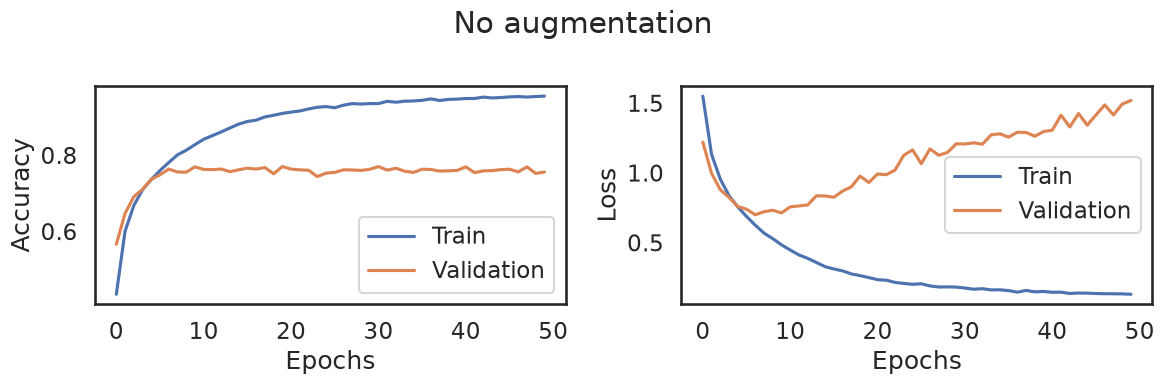

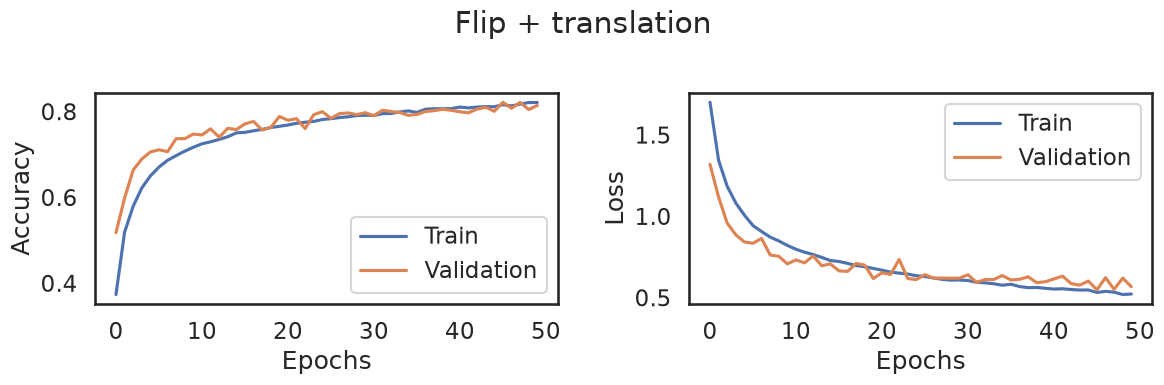

In [13]:
plot_history(history_noaug, title='No augmentation')
plot_history(history_aug, title='Flip + translation')

The accuracy is not the interesting quantity here. The claim about augmentation is a claim about *regularization*, so the thing to look at is the quantity regularization is supposed to shrink: the gap between training and validation accuracy.

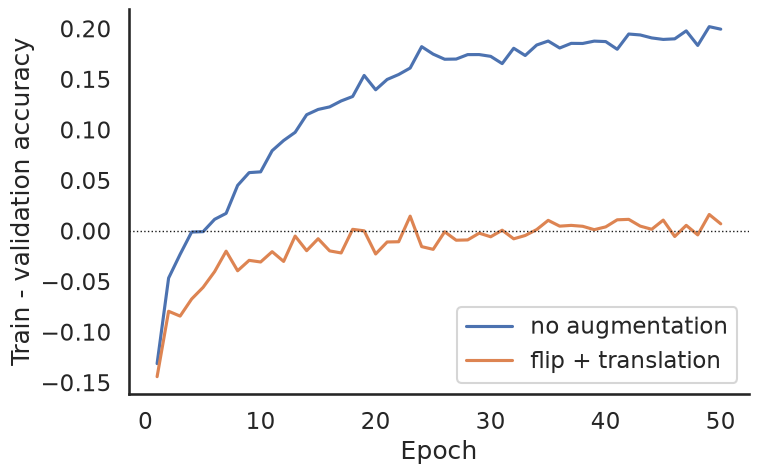

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, history, _ in ARMS:
    gap = np.array(history['accuracy']) - np.array(history['val_accuracy'])
    ax.plot(np.arange(1, len(gap) + 1), gap, label=label)
ax.axhline(0, ls=':', c='k', lw=1)
ax.set(xlabel='Epoch', ylabel='Train - validation accuracy')
ax.legend()
sns.despine()

The unaugmented curve climbs steadily: its two accuracies pull apart epoch after epoch. The augmented one stays flat and near zero. Put the final epoch's numbers side by side:

In [15]:
print('{:<22s}{:>9s}{:>13s}{:>8s}'.format('', 'train', 'validation', 'gap'))
for label, history, _ in ARMS:
    train, val = history['accuracy'][-1], history['val_accuracy'][-1]
    print('{:<22s}{:>9.2%}{:>13.2%}{:>8.2%}'.format(label, train, val, train - val))

                          train   validation     gap
no augmentation          95.52%       75.58%  19.94%
flip + translation       82.09%       81.40%   0.69%


## The gap, measured honestly

There is something wrong with the number we just printed, and it is worth stopping on, because it is an easy way to fool yourself.

`history['accuracy']` is the accuracy Keras accumulated *during* the training epoch. That means two things:

1. it is measured with **dropout active**, so it understates what the model can actually do; and
2. for the augmented arm it is measured **on the augmented images** — the shifted, mirrored, harder ones — while validation accuracy is measured on clean images.

So the two arms' training accuracies are not measurements of the same quantity, and subtracting is not quite like for like. The augmented arm's gap above is 0.69 points, which looks like a model that has stopped overfitting entirely — but part of that is simply that its training images were harder than its validation ones. (Run this notebook yourself and the augmented gap may well come out *negative*, which would be even more obviously an artifact: no model generalizes better than perfectly.)

The fix is to measure both models the same way: on the **clean** training images, in inference mode, where dropout is off and the augmentation layers are inert.

In [16]:
print('{:<22s}{:>9s}{:>13s}{:>8s}'.format('on clean data', 'train', 'validation', 'gap'))
for label, _, model in ARMS:
    train = (model.predict(X_train, batch_size=512, verbose=0).argmax(axis=1)
             == Y_train.argmax(axis=1)).mean()
    val = (model.predict(X_validation, batch_size=512, verbose=0).argmax(axis=1)
           == Y_validation.argmax(axis=1)).mean()
    print('{:<22s}{:>9.2%}{:>13.2%}{:>8.2%}'.format(label, train, val, train - val))

on clean data             train   validation     gap


no augmentation          99.08%       75.58%  23.50%


flip + translation       86.82%       81.40%   5.42%


# Discussion

**Augmentation is worth 5.8 points of validation accuracy here** — 75.58% without it, 81.40% with it, both at epoch 50. The standard error of an accuracy estimated on 10,000 validation images is about 0.39 points, so a 5.8-point difference is far outside the noise.

**Do not read anything into differences of a point or less.** We ran this notebook twice, unchanged, with the same `SEED` on the same GPU: the unaugmented arm finished at 76.49% the first time and 75.58% the second, and the augmented arm at 81.73% and 81.40%. Setting a seed fixes the initialization and the shuffling, but floating-point reductions on a GPU are not bit-reproducible, so roughly a point of slack is built in. That is the yardstick for every other number in this notebook.

**What augmentation did was close the generalization gap.** Measured the same way on clean images, the unaugmented model reaches 99.08% on the training set against 75.58% on validation; the augmented model reaches 86.82% against 81.40%. The gap falls from 23.50 points to 5.42, a factor of 4.3. The unaugmented network has essentially memorized 50,000 images, and that memorization bought it nothing on unseen ones.

**The unaugmented run peaked early and then got worse.** Its best validation accuracy, 77.03%, arrived at epoch 20; by epoch 50 it had drifted down to 75.58% while its training accuracy kept climbing. We report epoch 50, not the peak. With no early stopping and nothing selected on the validation set, the final-epoch number is the honest one — and the drift is itself the lesson, because it is what overfitting looks like from the outside. Over its last ten epochs its validation accuracy was falling at about 0.06 points per epoch.

**The augmented run had not finished.** Over its last ten epochs its validation accuracy was still rising, at about 0.17 points per epoch. So 5.8 points is a *lower bound* on what this recipe is worth: augmentation slows fitting down, and at any fixed epoch budget the comparison understates it. This is the main confound in the experiment. We gave both arms the same number of epochs rather than the same wall-clock time, which is the fairer of the two choices but not a neutral one.

**It is not "more data".** We did not add a single image — the sample size is exactly 50,000 in both arms. What changed is the hypothesis class. By showing the network shifted and mirrored copies of an image with the label unchanged, we pushed it towards functions that are invariant to shifting and mirroring; and that invariance happens to be true of photographs, which is why it helps. Pick a transformation the world does *not* respect and the same mechanism will hurt you, which is exactly why `RandomFlip` is restricted to `'horizontal'` here.

**It is also not free, and not always worth it.** The gain came at 73x the training time, entirely because of one layer. And a network that was not overfitting would have nothing to gain: augmentation is a regularizer, so it pays in proportion to how much the model is memorizing. Our 620,362-parameter network on 50,000 images is squarely in that regime; the pretrained 20-million-parameter backbone in the [transfer learning session](transfer.ipynb) is not, and there a horizontal flip was worth only 0.4%.

**You have already used augmentation in this course under another name.** The [audio session](audio.ipynb) cuts every clip into 17 overlapping segments and trains on all of them — that is augmentation by time-shift — and at prediction time it averages the model's scores across a clip's segments, which is test-time augmentation, the subject of the last section below.

# Exercise

`augment_simple` is deliberately the minimal recipe, so there is room above it. Build a heavier one and find out whether it helps:

```python
augment_heavy = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.125, 0.125, fill_mode='constant', fill_value=0.0),
    # your additions here
], name='augment_heavy')
```

Add `RandomRotation`, `RandomContrast` and `RandomErasing`, and optionally `RandomZoom`. Then retrain with `build_model(augment=augment_heavy)` and report whether the extra transformations bought anything.

Four things to know before you start:

- **`value_range=(0, 1)`** for `RandomContrast` and `RandomErasing`, as explained above. This is the trap of the three that will actually bite you here.
- **CIFAR objects are upright.** Keep the rotation small — `factor=0.05` is about $\pm 18°$. Large rotations will hurt, and it is worth finding out how much by trying one.
- **`RandomErasing` is dropout in input space**, with spatial structure: it blanks a contiguous rectangle rather than scattered independent pixels, which is what makes it a different constraint from the `Dropout` layer already in the model ([Zhong et al. 2020](https://arxiv.org/abs/1708.04896), [DeVries & Taylor 2017](https://arxiv.org/abs/1708.04552)).
- **Use a reduced budget**, 20 epochs rather than 50, so this is feasible. Compare against the first 20 epochs of the two runs above, not against their final numbers.

Report the final-epoch training accuracy, validation accuracy and the gap, as in the table above. A worked answer is in [the solution notebook](../solutions/augmentation.ipynb).

# Test-time augmentation

One last idea, which costs nothing to try. The augmentation layers are inactive at inference — but nothing stops us from augmenting at inference *deliberately*, predicting on several versions of each image and averaging.

The cheapest version is the horizontal flip we trained with: predict on the image and on its mirror, and average the two softmax outputs.

In [17]:
probs = model_aug.predict(X_validation, batch_size=512, verbose=0)
probs_flipped = model_aug.predict(X_validation[:, :, ::-1, :], batch_size=512, verbose=0)

truth = Y_validation.argmax(axis=1)
for label, p in (('plain', probs),
                 ('flipped', probs_flipped),
                 ('averaged (TTA)', (probs + probs_flipped) / 2)):
    print('{:<16s}{:>8.2%}'.format(label, (p.argmax(axis=1) == truth).mean()))

plain             81.40%
flipped           81.61%
averaged (TTA)    83.14%


Averaging over an image and its mirror is worth **1.7 points** — 81.40% to 83.14% — for one extra forward pass and no training whatsoever.

The flipped view scores 81.61% on its own, a shade *above* the plain 81.40%, and that is the whole point. The two views are equally good, but they make *different* mistakes, so averaging their probabilities cancels part of the error. This is the cheapest ensemble there is.

It works here because we *trained* with horizontal flips, so the model has been taught that the two views mean the same thing. It is the same trick the [audio session](audio.ipynb) uses when it averages a clip's segment scores, and it is worth remembering whenever inference time is cheap relative to the cost of being wrong.

# References

- [Krizhevsky 2009](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf), *Learning Multiple Layers of Features from Tiny Images* — the CIFAR-10 technical report.
- [Shorten & Khoshgoftaar 2019](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0197-0), *A survey on image data augmentation for deep learning*.
- [DeVries & Taylor 2017](https://arxiv.org/abs/1708.04552), *Improved regularization of convolutional neural networks with Cutout*.
- [Zhong et al. 2020](https://arxiv.org/abs/1708.04896), *Random Erasing data augmentation*.
- Keras [image augmentation layers](https://keras.io/api/layers/preprocessing_layers/image_augmentation/) — the full list, including `RandAugment`, `CutMix` and `MixUp`.
- [Transfer learning](transfer.ipynb), where augmentation appears as one of the levers we did not measure.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)